In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../Student_Data/StudentsPerformance.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()
print(df.dtypes)

Shape: (1000, 8)

First 5 rows:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [2]:
# Check missing values
print("Missing Values:")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0].head(15))

print("\nBasic Statistics:")
print(df.describe())

Missing Values:
Series([], dtype: int64)

Basic Statistics:
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000000      57.750000
50%      66.00000      70.000000      69.000000
75%      77.00000      79.000000      79.000000
max     100.00000     100.000000     100.000000


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'Final_Score', 'Pass'],
      dtype='object')


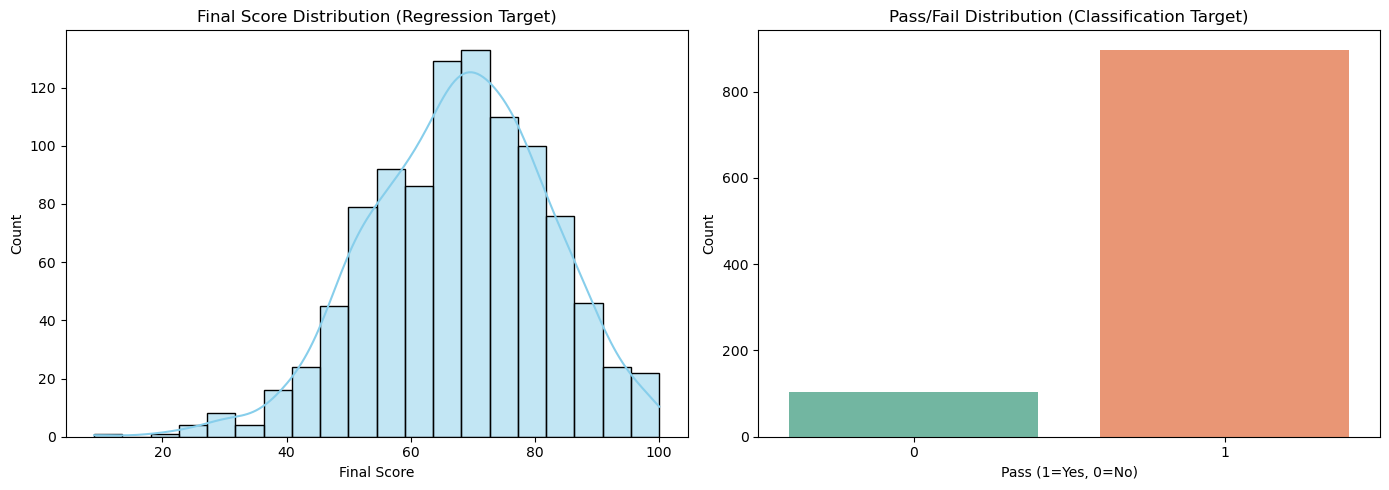

In [3]:
# Create new features
df['Final_Score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3
df['Pass'] = (df['Final_Score'] >= 50).astype(int)
print(df.columns)

# Visualize Targets
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 - Final Score Distribution
sns.histplot(df['Final_Score'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Final Score Distribution (Regression Target)')
axes[0].set_xlabel('Final Score')
axes[0].set_ylabel('Count')

# Chart 2 - Pass/Fail Distribution
sns.countplot(x='Pass', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Pass/Fail Distribution (Classification Target)')
axes[1].set_xlabel('Pass (1=Yes, 0=No)')
axes[1].set_ylabel('Count')

plt.tight_layout()

plt.show()

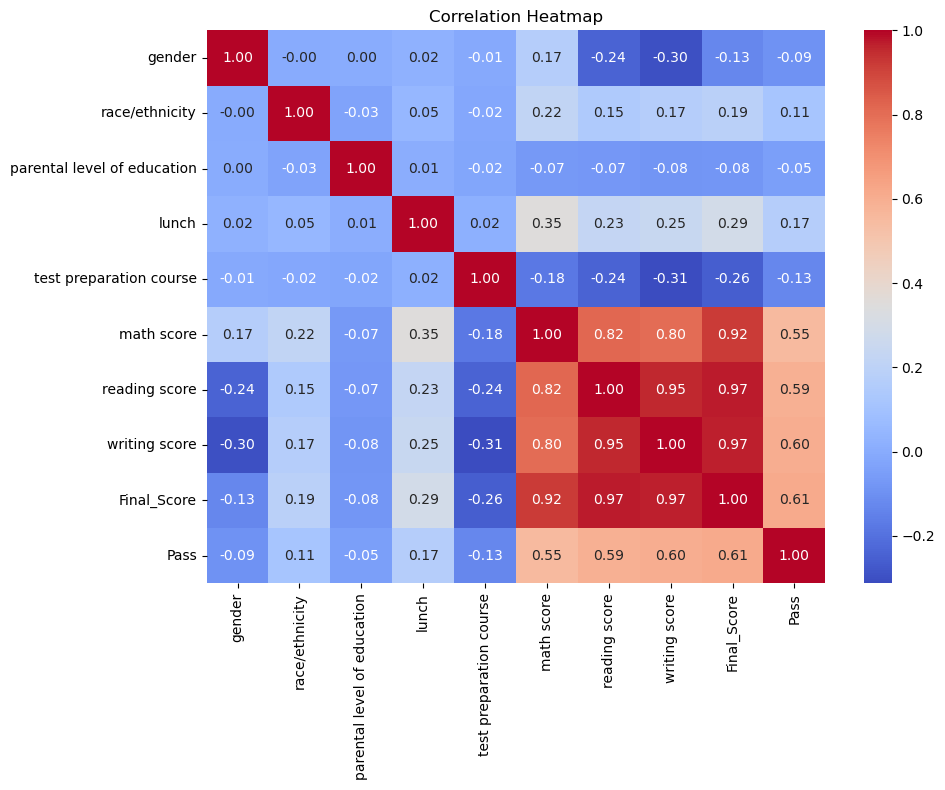

In [4]:
# Encode categorical variables
categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Heatmap of all features
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


In [5]:
# Select top features (Feature Selection)
# Exclude raw scores to prevent data leakage
features = categorical_cols

# Prepare data
X = df[features].copy()
y_reg = df['Final_Score'].copy()  # Regression target
y_clf = df['Pass'].copy()         # Classification target

# 1. Handle missing values properly (Impute with Median for safety)
for col in features:
    X[col] = X[col].fillna(X[col].median())

# Split data for Regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# Split data for Classification
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_clf, test_size=0.2, random_state=42
)

print("Training set size:", X_train_reg.shape)
print("Testing set size:", X_test_reg.shape)

print("\nPredicting Final Score(Regression)\n")
# Train Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg, y_train_reg)
lin_acc = r2_score(y_test_reg, lin_reg.predict(X_test_reg))

# Train Decision Tree Regressor
dt_reg = DecisionTreeRegressor(random_state=42)
dt_reg.fit(X_train_reg, y_train_reg)
dt_reg_acc = r2_score(y_test_reg, dt_reg.predict(X_test_reg))

# Train Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_reg, y_train_reg)
rf_reg_acc = r2_score(y_test_reg, rf_reg.predict(X_test_reg))

print(f"Linear Regression       - R2 Score: {lin_acc:.4f}")
print(f"Decision Tree Regressor - R2 Score: {dt_reg_acc:.4f}")
print(f"Random Forest Regressor - R2 Score: {rf_reg_acc:.4f}")

print("\nPredicting Pass/Fail(Classification)\n")
# Train Logistic Regression
lr_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_clf.fit(X_train_clf, y_train_clf)
lr_clf_acc = accuracy_score(y_test_clf, lr_clf.predict(X_test_clf))

# Train Decision Tree Classifier
dt_clf = DecisionTreeClassifier(random_state=42, class_weight='balanced')
dt_clf.fit(X_train_clf, y_train_clf)
dt_clf_acc = accuracy_score(y_test_clf, dt_clf.predict(X_test_clf))

# Train Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_clf, y_train_clf)
rf_clf_acc = accuracy_score(y_test_clf, rf_clf.predict(X_test_clf))

print(f"Logistic Regression     - Accuracy: {lr_clf_acc:.4f}")
print(f"Decision Tree Classifier- Accuracy: {dt_clf_acc:.4f}")
print(f"Random Forest Classifier- Accuracy: {rf_clf_acc:.4f}")

Training set size: (800, 5)
Testing set size: (200, 5)

Predicting Final Score(Regression)

Linear Regression       - R2 Score: 0.1256
Decision Tree Regressor - R2 Score: -0.0933
Random Forest Regressor - R2 Score: -0.0286

Predicting Pass/Fail(Classification)

Logistic Regression     - Accuracy: 0.6550
Decision Tree Classifier- Accuracy: 0.7150
Random Forest Classifier- Accuracy: 0.7750
